<a href="https://colab.research.google.com/github/Kriti-2180/Deep-Learning/blob/main/Activation_Function_ReLU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, PReLU, ELU, Activation

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
X, y = make_moons(
    n_samples=1000,
    noise=0.25,
    random_state=42
)

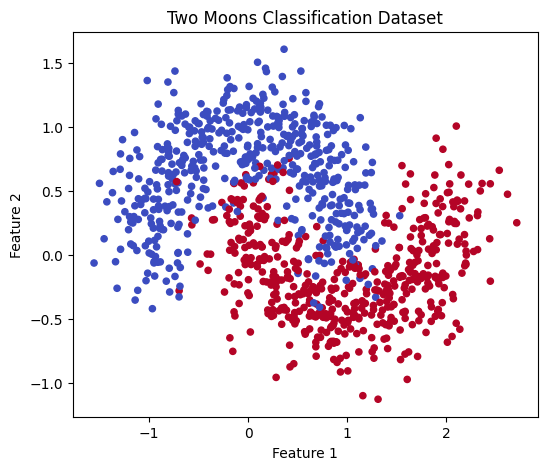

In [4]:
plt.figure(figsize=(6, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="coolwarm",
    s=20
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Two Moons Classification Dataset")

plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
def add_activation(model, activation_name):

    if activation_name == "relu":
        model.add(Activation("relu"))

    elif activation_name == "leaky_relu":
        model.add(LeakyReLU(negative_slope=0.1))

    elif activation_name == "prelu":
        model.add(PReLU())

    elif activation_name == "elu":
        model.add(ELU(alpha=1.0))

    elif activation_name == "selu":
        model.add(Activation("selu"))

    else:
        raise ValueError("Unknown activation name")


def build_model(activation_name):

    model = Sequential()

    model.add(Dense(32, input_shape=(2,)))
    add_activation(model, activation_name)

    model.add(Dense(32))
    add_activation(model, activation_name)

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [8]:
activation_list = [
    "relu",
    "leaky_relu",
    "prelu",
    "elu",
    "selu"
]

histories = {}
results = {}

for activation in activation_list:

    print("\nTraining model with:", activation)

    model = build_model(activation)

    history = model.fit(
        X_train_scaled,
        y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test_scaled, y_test),
        verbose=0
    )

    test_loss, test_accuracy = model.evaluate(
        X_test_scaled,
        y_test,
        verbose=0
    )

    histories[activation] = history
    results[activation] = test_accuracy

    print(
        activation,
        "Test Accuracy:",
        round(test_accuracy, 4)
    )


Training model with: relu


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


relu Test Accuracy: 0.97

Training model with: leaky_relu
leaky_relu Test Accuracy: 0.965

Training model with: prelu
prelu Test Accuracy: 0.96

Training model with: elu
elu Test Accuracy: 0.865

Training model with: selu
selu Test Accuracy: 0.96


In [9]:
print("\nFinal Accuracy Comparison")
print("-------------------------")

for activation, accuracy in results.items():
    print(
        activation,
        ":",
        round(accuracy, 4)
    )


Final Accuracy Comparison
-------------------------
relu : 0.97
leaky_relu : 0.965
prelu : 0.96
elu : 0.865
selu : 0.96


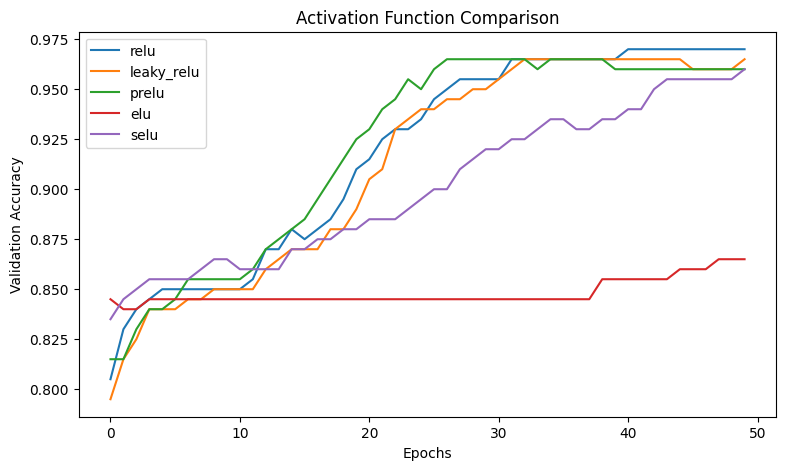

In [10]:
plt.figure(figsize=(9, 5))

for activation in activation_list:
    plt.plot(
        histories[activation].history["val_accuracy"],
        label=activation
    )

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Activation Function Comparison")

plt.legend()
plt.show()

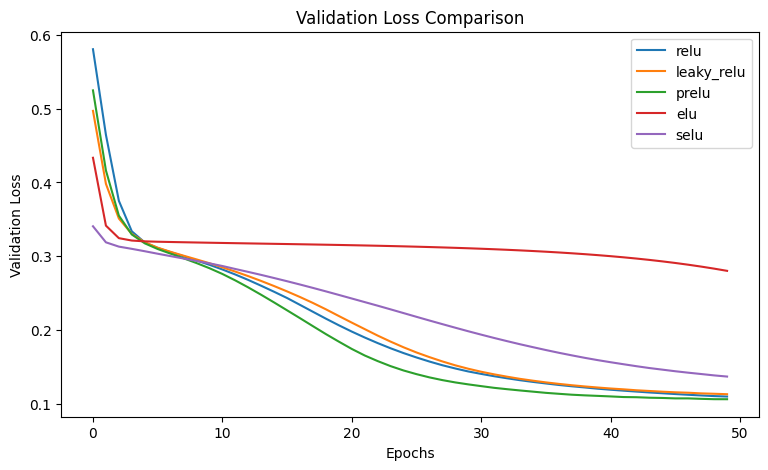

In [11]:
plt.figure(figsize=(9, 5))

for activation in activation_list:
    plt.plot(
        histories[activation].history["val_loss"],
        label=activation
    )

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")

plt.legend()
plt.show()